<a href="https://colab.research.google.com/github/mtnleo/Uni_AI_1/blob/main/Guia4_Leonardi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#UNIVERSIDAD ATLANTIDA ARGENTINA
#INTELIGENCIA ARTIFICIAL 1

##PRACTICA 4

###TEMAS
* CLUSTERING
* MEDIDAS DE DISTANCIA
* K-MEANS

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_iris

# Cargar dataset
iris = load_iris()
nombre_archivo = '/content/drive/MyDrive/seeds_dataset.xlsx'

##Ejercicios Prácticos
Utilice los códigos del material de consulta (K_means.ipynb , Introduccion_Python_Colab.ipynb, Tutorial_Pandas, Tutorial_Scikit_learn.ipynb) y los conceptos vistos en teoria para resolver los siguientes ejercicios.

**Ejercicio 1:**
Calcule la distancia de cada uno de los siguientes puntos al centroide con valor [6,12000] utilizando las siguientes medidas de distancia:
* Euclídea
* Manhattan

Luego, a los valores originales de la variable X súmele un 10% , no altere el centroide y recalcule las distancias.
Normalice, calcule las distancias y analice los
resultados comparándolos con los obtenidos con las variables sin normalizar.




In [10]:
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler # Normalizar
centroide = np.array([6, 12000])
datos = np.array([
    [3, 4500],
    [5, 6000],
    [9, 17000]
])
print("\nMatriz completa X Y:")
print(datos)



Matriz completa X Y:
[[    3  4500]
 [    5  6000]
 [    9 17000]]


In [6]:
# Método manual con raíz cuadrada de suma de cuadrados para distancia euclidea
def distancia_euclidea(punto1, punto2):
    distancia = np.sqrt(np.sum((punto1 - punto2) ** 2))
    return distancia


In [7]:
distancia_punto1 = distancia_euclidea(centroide, datos[0])
print("Distancia al centroide para el punto 1:", distancia_punto1)


Distancia al centroide para el punto 1: 7500.000599999976


In [18]:
# EUCLIDEA: Sin normalizar
print("---------------- EUCLIDEA: Sin normalizar ----------------")
distancia_punto1 = distancia_euclidea(centroide, datos[0])
distancia_punto2 = distancia_euclidea(centroide, datos[1])
distancia_punto3 = distancia_euclidea(centroide, datos[2])
print("Distancia al centroide para el punto 1:", distancia_punto1)
print("Distancia al centroide para el punto 2:", distancia_punto2)
print("Distancia al centroide para el punto 3:", distancia_punto3)

print("---------------- EUCLIDEA: Sin normalizar + 10% en X ----------------")
# Hacemos una copia asegurando que los datos sean tipo float (para no perder decimales al multiplicar por 1.1)
datos_modificados = np.array(datos, dtype=float)

# Multiplicamos SOLO la columna X (todas las filas de la columna 0) por 1.1
datos_modificados[:, 0] *= 1.1

m_distancia_punto1 = distancia_euclidea(centroide, datos_modificados[0])
m_distancia_punto2 = distancia_euclidea(centroide, datos_modificados[1])
m_distancia_punto3 = distancia_euclidea(centroide, datos_modificados[2])
print("Distancia al centroide para el punto 1:", m_distancia_punto1)
print("Distancia al centroide para el punto 2:", m_distancia_punto2)
print("Distancia al centroide para el punto 3:", m_distancia_punto3)

# EUCLIDEA: Normalizado
print("---------------- EUCLIDEA: Normalizado ----------------")
df = pd.DataFrame(datos, columns=['X', 'Y'])
scaler = MinMaxScaler()
df_norm = scaler.fit_transform(df)
centroide_norm = scaler.transform([centroide])[0]
# print(df_norm)

n_distancia_punto1 = distancia_euclidea(centroide_norm, df_norm[0])
n_distancia_punto2 = distancia_euclidea(centroide_norm, df_norm[1])
n_distancia_punto3 = distancia_euclidea(centroide_norm, df_norm[2])
print("Distancia al centroide para el punto 1:", n_distancia_punto1)
print("Distancia al centroide para el punto 2:", n_distancia_punto2)
print("Distancia al centroide para el punto 3:", n_distancia_punto3)

#####
#####
#####
def distancia_manhattan(punto1, punto2):
    distancia = np.abs(punto1[0] - punto2[0]) + np.abs(punto1[1] - punto2[1])
    return distancia

# MANHATTAN: Sin Normalizar
print("---------------- MANHATTAN: Sin Normalizar ----------------")
distancia_manhattan_punto1 = distancia_manhattan(centroide, datos[0])
distancia_manhattan_punto2 = distancia_manhattan(centroide, datos[1])
distancia_manhattan_punto3 = distancia_manhattan(centroide, datos[2])
print("Distancia al centroide para el punto 1:", distancia_manhattan_punto1)
print("Distancia al centroide para el punto 2:", distancia_manhattan_punto2)
print("Distancia al centroide para el punto 3:", distancia_manhattan_punto3)

print("---------------- MANHATTAN: Sin normalizar + 10% en X ----------------")
# Hacemos una copia asegurando que los datos sean tipo float (para no perder decimales al multiplicar por 1.1)
datos_modificados = np.array(datos, dtype=float)

# Multiplicamos SOLO la columna X (todas las filas de la columna 0) por 1.1
datos_modificados[:, 0] *= 1.1

m_distancia_manhattan_punto1 = distancia_manhattan(centroide, datos_modificados[0])
m_distancia_manhattan_punto2 = distancia_manhattan(centroide, datos_modificados[1])
m_distancia_manhattan_punto3 = distancia_manhattan(centroide, datos_modificados[2])
print("Distancia al centroide para el punto 1:", m_distancia_manhattan_punto1)
print("Distancia al centroide para el punto 2:", m_distancia_manhattan_punto2)
print("Distancia al centroide para el punto 3:", m_distancia_manhattan_punto3)

# MANHATTAN: Normalizado
print("----------------  MANHATTAN: Normalizado ----------------")
n_distancia_manhattan_punto1 = distancia_manhattan(centroide_norm, df_norm[0])
n_distancia_manhattan_punto2 = distancia_manhattan(centroide_norm, df_norm[1])
n_distancia_manhattan_punto3 = distancia_manhattan(centroide_norm, df_norm[2])
print("Distancia al centroide para el punto 1:", n_distancia_manhattan_punto1)
print("Distancia al centroide para el punto 2:", n_distancia_manhattan_punto2)
print("Distancia al centroide para el punto 3:", n_distancia_manhattan_punto3)

---------------- EUCLIDEA: Sin normalizar ----------------
Distancia al centroide para el punto 1: 7500.000599999976
Distancia al centroide para el punto 2: 6000.000083333332
Distancia al centroide para el punto 3: 5000.000899999919
---------------- EUCLIDEA: Sin normalizar + 10% en X ----------------
Distancia al centroide para el punto 1: 7500.000485999984
Distancia al centroide para el punto 2: 6000.000020833333
Distancia al centroide para el punto 3: 5000.001520999769
---------------- EUCLIDEA: Normalizado ----------------
Distancia al centroide para el punto 1: 0.7810249675906655
Distancia al centroide para el punto 2: 0.5081119736610995
Distancia al centroide para el punto 3: 0.6403124237432848
---------------- MANHATTAN: Sin Normalizar ----------------
Distancia al centroide para el punto 1: 7503
Distancia al centroide para el punto 2: 6001
Distancia al centroide para el punto 3: 5003
---------------- MANHATTAN: Sin normalizar + 10% en X ----------------
Distancia al centroide p

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(




**Ejercicio 2:** Responda las siguientes consignas.
* ¿Qué es un algoritmo de *clustering*, qué se requiere para utilizarlo y cuál es su salida?
* ¿Cómo asigna nuevos datos a alguno de los clusters?
* Enumere los pasos del algoritmo *k-means* (HCM) sin matemática.
* Cuales son los posibles hiperparametros de *k-means*.

---

**¿Qué es un algoritmo de clustering, qué se requiere para utilizarlo y cuál es su salida?**
*   **Qué es:** Es una técnica de **aprendizaje automático no supervisado** cuyo objetivo es dividir un conjunto heterogéneo de datos sin etiquetar en subgrupos homogéneos (llamados clusters) descubriendo su estructura inherente. Busca que las observaciones dentro del mismo cluster sean muy similares entre sí (alta cohesión intra-cluster) y muy distintas a las de otros clusters (alto aislamiento inter-cluster).
*   **Qué se requiere:** Se requiere proporcionar los **datos de entrada (sin etiquetas o salidas deseadas)** y definir una **medida de distancia o similitud** (como la euclídea o la similitud coseno) para calcular qué tan parecidos son los datos. Para los algoritmos basados en particiones (como K-means), también se requiere definir a priori la **cantidad de clusters ($k$)** que se desean encontrar.
*   **Cuál es su salida:** Su salida es el conjunto de datos originales divididos en la cantidad de grupos establecida, junto con los **centroides** (o prototipos), que son los modelos generadores o puntos representativos que "resumen" cada uno de los agrupamientos formados.

**¿Cómo asigna nuevos datos a alguno de los clusters?**
La asignación se realiza calculando la similitud entre el dato y los modelos generadores de cada grupo. Específicamente, el algoritmo toma el nuevo dato, mide su distancia frente a cada uno de los centroides existentes utilizando una métrica definida (generalmente la distancia euclidiana), y **lo asigna al cluster cuyo centroide se encuentre más cercano**.

**Enumere los pasos del algoritmo k-means (HCM) sin matemática.**
1.  **Inicialización:** Se elige la cantidad de clusters deseados ($k$) y se seleccionan aleatoriamente $k$ puntos como los centros iniciales de cada cluster (centroides).
2.  **Asignación:** Se evalúa la distancia de cada punto del conjunto de datos frente a todos los centroides y se asigna cada punto al cluster del centroide más cercano.
3.  **Actualización:** Se recalcula la posición de cada centroide tomando el promedio (o la media) de las coordenadas de todos los puntos que fueron asignados a ese cluster en el paso anterior.
4.  **Iteración y Detención:** Se verifica el criterio de detención, el cual evalúa si los nuevos centroides cambiaron de posición respecto a la iteración previa. Si los centroides son iguales (ya no se mueven) o si se alcanzó un número máximo de iteraciones, el algoritmo se detiene. De lo contrario, se vuelve al paso 2.

**Cuáles son los posibles hiperparámetros de k-means.**
Según los parámetros necesarios para guiar el modelo (por ejemplo, en la librería scikit-learn), los principales hiperparámetros son:
*   **El número de clusters ($k$):** La cantidad de grupos en los que se dividirá el conjunto de datos (ej. `n_clusters`).
*   **Cantidad de inicializaciones aleatorias:** Define cuántas veces se ejecutará el algoritmo con diferentes semillas iniciales para los centroides, quedándose con el mejor resultado (ej. `n_init`).
*   **Número máximo de iteraciones:** El tope de veces que el algoritmo repetirá los pasos de asignación y actualización si no logra la convergencia (detención) antes de ese límite.
*   **Semilla aleatoria:** Un número para garantizar que la inicialización aleatoria de los centroides iniciales sea reproducible (ej. `random_state`).


**Ejercicio 3:** Algoritmo *k-means* sin librerias.

Programa tu propio algoritmo K-Means sin usar la libreria de sklearn. Puedes usar numpy, pandas, etc.


El algoritmo convergió en la iteración 4


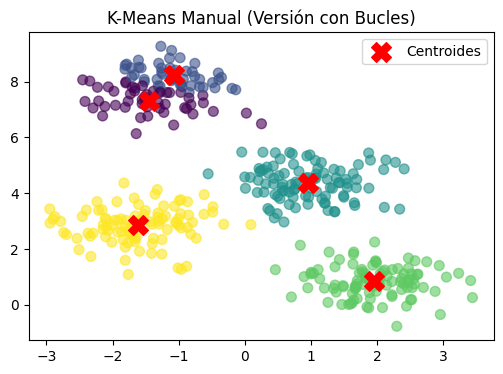

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

def distancia_euclidea(punto1, punto2):
    return np.sqrt(np.sum((punto1 - punto2) ** 2))

def kmeans(X, k, max_iters=100):
    # 1. Inicialización: Elegir 'k' índices al azar para los primeros centroides
    np.random.seed(42) # Para que siempre dé el mismo resultado en las pruebas
    indices = np.random.choice(len(X), k, replace=False)
    centroides = X[indices]

    for iteracion in range(max_iters):
        etiquetas = []

        # 2. Asignación: Recorrer cada punto uno por uno
        for punto in X:
            distancias = []
            # Medir la distancia de este punto contra todos los centroides
            for centroide in centroides:
                dist = distancia_euclidea(punto, centroide)
                distancias.append(dist)

            # El cluster asignado es el que tiene la distancia mínima
            cluster_mas_cercano = np.argmin(distancias)
            etiquetas.append(cluster_mas_cercano)

        etiquetas = np.array(etiquetas)

        # 3. Actualización: Recalcular la posición de los centroides
        nuevos_centroides = []
        for j in range(k):
            # Filtrar solo los puntos que pertenecen al cluster actual (j)
            puntos_cluster = X[etiquetas == j]

            # Calcular el promedio (la media) de esos puntos
            nuevo_centro = puntos_cluster.mean(axis=0)
            nuevos_centroides.append(nuevo_centro)

        nuevos_centroides = np.array(nuevos_centroides)

        # 4. Detención: Si los centroides no se movieron, el algoritmo convergió
        if np.array_equal(centroides, nuevos_centroides):
            print(f"El algoritmo convergió en la iteración {iteracion + 1}")
            break

        centroides = nuevos_centroides

    return etiquetas, centroides



# --- Prueba del código ---
X_blobs, y_blobs = make_blobs(n_samples=400, centers=4, cluster_std=0.60, random_state=0)
etiquetas_pred, centros_finales = kmeans(X_blobs, k=5)

# Visualización
plt.figure(figsize=(6, 4))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=etiquetas_pred, cmap='viridis', s=50, alpha=0.6)
plt.scatter(centros_finales[:, 0], centros_finales[:, 1], c='red', marker='X', s=200, label='Centroides')
plt.title('K-Means Manual ')
plt.legend()
plt.show()

**Ejercicio 4:** Utilizando la función *make_blobs* de sklearn.datasets import make_blobs
1.  Genere un conjunto de datos sinteticos de 400 muestras pertenecientes a 4 grupos o clases.
2.  Guardelos en un dataframe con sus respectivas columnas identificadas.
3. Visualize los datos sin las etiquetas
4. Estandarizar los datos media 0 y desviacion estandar 1.
5. Entrenar un modelo *K-means*  utilizando *from sklearn.cluster import KMeans*

---

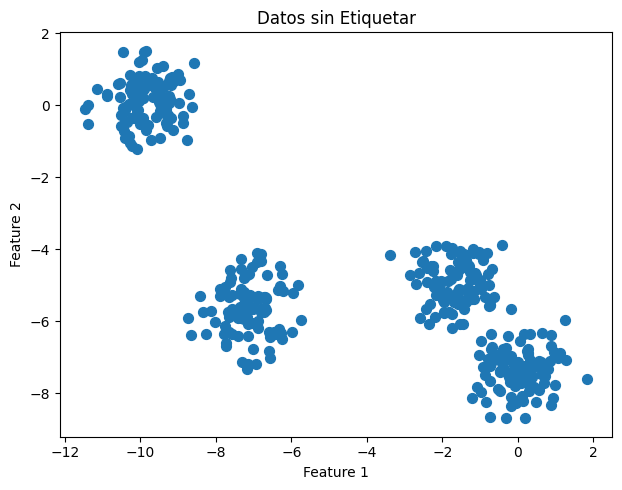

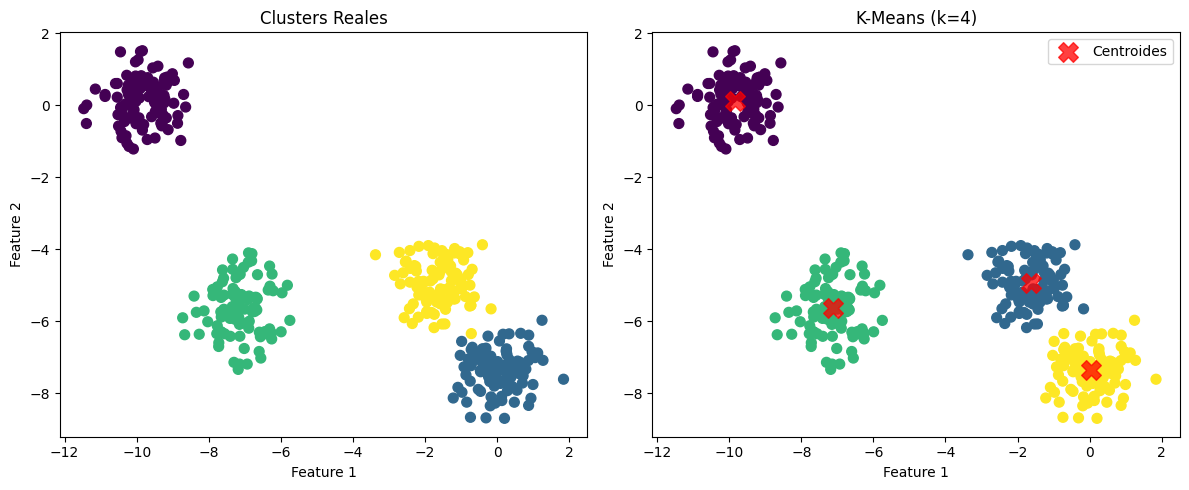

In [33]:
# EJERCICIO 4.
# 1. Genere un conjunto de datos sinteticos de 400 muestras pertenecientes a 4 grupos o clases.
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler, MinMaxScaler # 4.
from sklearn.cluster import KMeans # 5.


X_blobs, y_blobs = make_blobs(n_samples=400, centers=4, cluster_std=0.60, random_state=9)


# 2. Guardelos en un dataframe con sus respectivas columnas identificadas.
df_blobs = pd.DataFrame(X_blobs, columns=['Feature1', 'Feature2'])
df_blobs['Cluster_Real'] = y_blobs


# 3. Visualize los datos sin las etiquetas
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 2)
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], s=50)
plt.title('Datos sin Etiquetar')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.tight_layout()
plt.show()

# 4. Estandarizar los datos media 0 y desviacion estandar 1.
scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X_blobs)


# 5. Entrenar un modelo K-means utilizando from sklearn.cluster import KMeans
    # Aplicar K-Means con 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_blobs)

    # Visualizar resultados
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_blobs, cmap='viridis', s=50)
plt.title('Clusters Reales')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.subplot(1, 2, 2)
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_kmeans, cmap='viridis', s=50)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='red', s=200, alpha=0.75, marker='X', label='Centroides')
plt.title('K-Means (k=4)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()

plt.tight_layout()
plt.show()


**Ejercicio 5: Clustering con datos reales**
1.  Carga el dataset de iris desde `sklearn.datasets.load_iris()`.
2.  Aplica K-Means para agrupar las flores basándote en sus características (ignora la etiqueta de especie).
3.  Compara los clusters encontrados por K-Means con las especies reales de las flores. ¿Qué tan bien se alinean?.

---

In [ ]:
#@title Resuelve aqui tu ejercicio

**Ejercicio 6: Experimentar con dataseet de semillas seeds_dataset.xlsx**
1.  Cargue el conjunto de datos de las semillas seeds_datasets.
2.  Luego Normalice y estandarice la serie.
3. Aplica K-Means para agrupar las flores basándote en sus características (ignora la etiqueta de especie), pruebe con distintos valores de K.
4. Compare con el agrupamiento original

---

In [ ]:
#@title Resuelve aqui tu ejercicio